# ⚙️ Operational Analysis

This notebook implements the tenth dimension of our analytical framework: **Operational Analysis**.

**Objective:** Analyzing workflow efficiency, payment method reliability, and order failure rates.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('ggplot')

# Load data
df = pd.read_csv('../Amazon.csv')

## 2. Order Fulfillment Status
Visualizing the real-time operational state of all orders.

C:\Users\shame\AppData\Local\Temp\ipykernel_21544\2443066939.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='coolwarm')


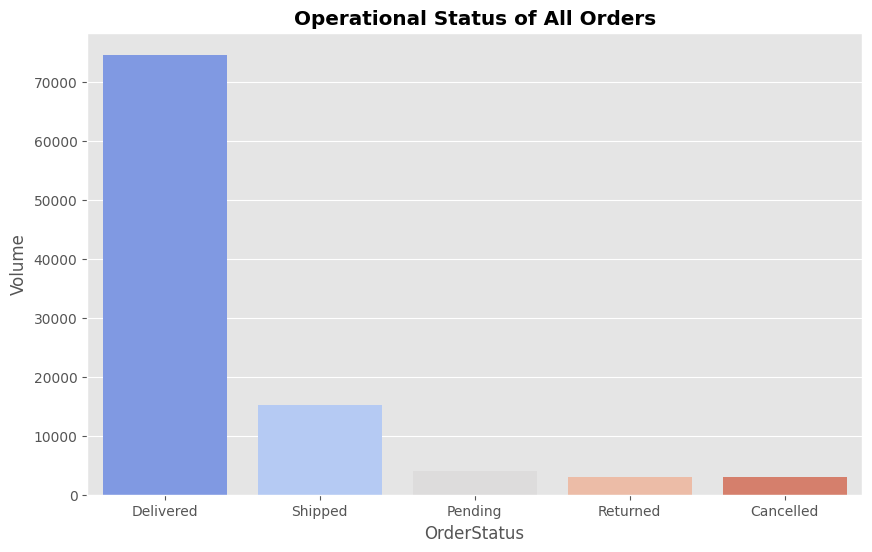

In [2]:
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='coolwarm')
plt.title('Operational Status of All Orders', fontweight='bold')
plt.ylabel('Volume')
plt.show()

## 3. Payment Method Efficiency
Which payment methods are most popular, and do they correlate with returns/cancellations?

<Figure size 1400x800 with 0 Axes>

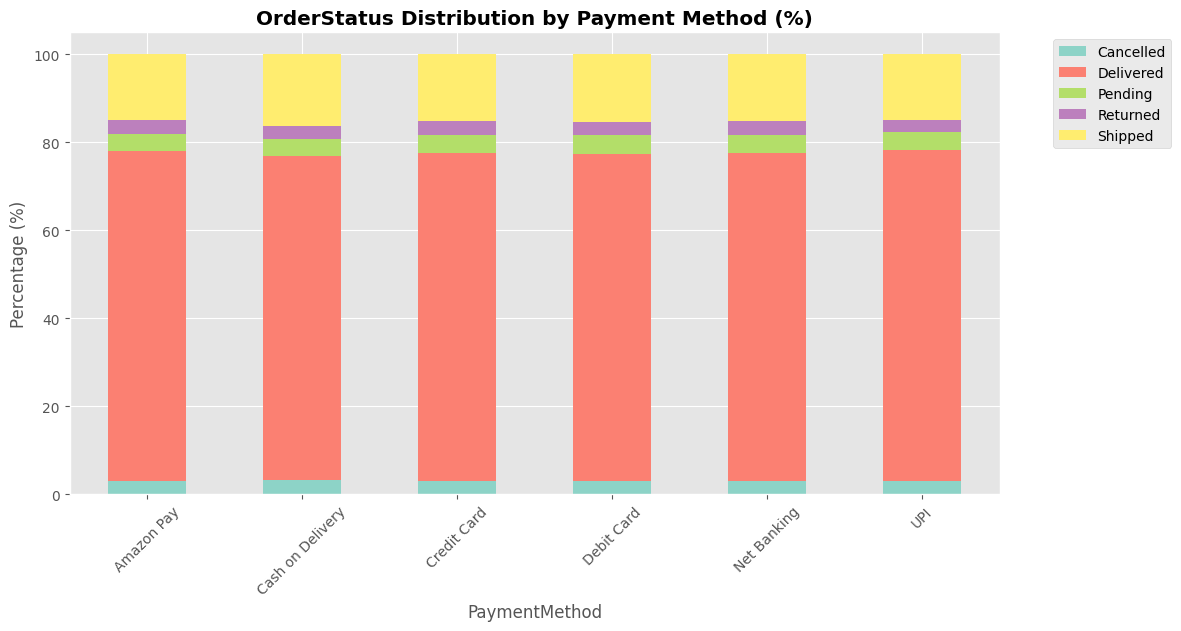

In [3]:
payment_stats = pd.crosstab(df['PaymentMethod'], df['OrderStatus'], normalize='index') * 100

plt.figure(figsize=(14, 8))
payment_stats.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set3')
plt.title('OrderStatus Distribution by Payment Method (%)', fontweight='bold')
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

## 4. Operational Friction Index
Calculating 'Failure Rate' (Cancelled + Returned) as a metric for supply chain and delivery friction.

Global Operational Friction Rate: 6.08%


C:\Users\shame\AppData\Local\Temp\ipykernel_21544\171578402.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_friction = df.groupby('Category').apply(lambda x: (x['OrderStatus'].isin(['Cancelled', 'Returned'])).mean() * 100).sort_values()


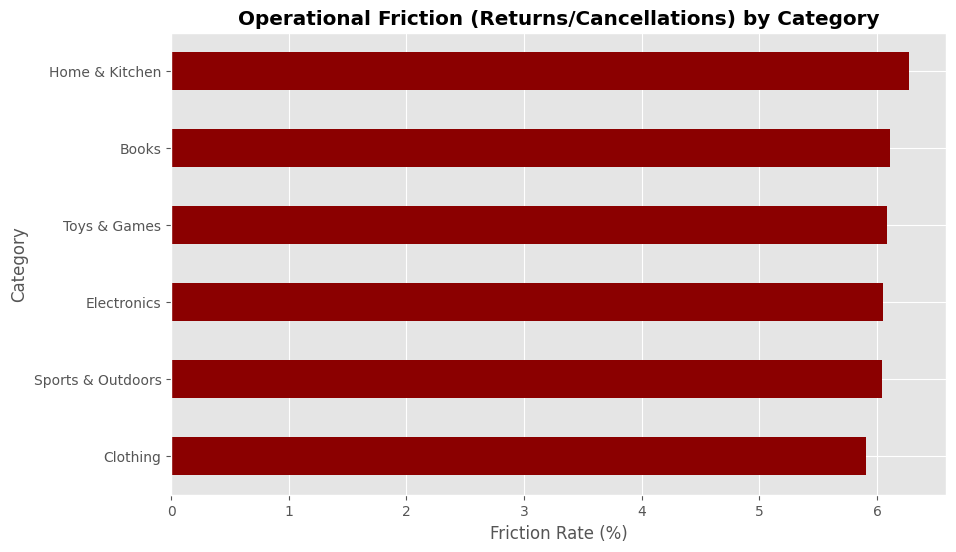

In [4]:
friction_rate = ((df['OrderStatus'].isin(['Cancelled', 'Returned'])).sum() / len(df)) * 100
print(f"Global Operational Friction Rate: {friction_rate:.2f}%")

category_friction = df.groupby('Category').apply(lambda x: (x['OrderStatus'].isin(['Cancelled', 'Returned'])).mean() * 100).sort_values()

plt.figure(figsize=(10, 6))
category_friction.plot(kind='barh', color='darkred')
plt.title('Operational Friction (Returns/Cancellations) by Category', fontweight='bold')
plt.xlabel('Friction Rate (%)')
plt.show()